In [56]:
# Cell 1: Nạp thư viện cần thiết
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import numpy as np
import matplotlib.pyplot as plt
import random

In [57]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Tên các nhãn của CIFAR10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Shape X_train:", X_train.shape)   # (50000, 32, 32, 3)
print("Shape X_test :", X_test.shape)    # (10000, 32, 32, 3)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (50000, 32, 32, 3)
Shape X_test : (10000, 32, 32, 3)
Shape y_train: (50000, 1)
Shape y_test : (10000, 1)


# Cell 3: Hiển thị 10 ảnh đầu tiên để kiểm tra dữ liệu

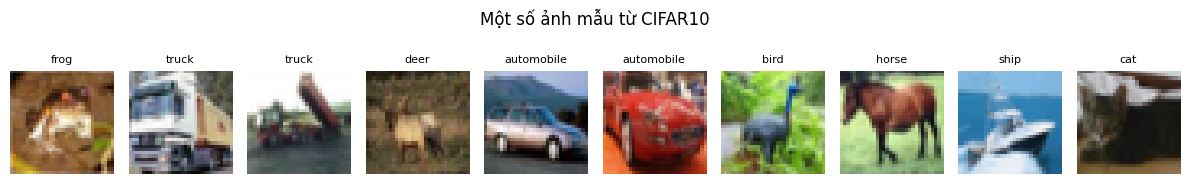

In [58]:

plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=8)
    plt.axis('off')
plt.suptitle("Một số ảnh mẫu từ CIFAR10")
plt.tight_layout()
plt.show()

# Cell 4: Tiền xử lý - Normalize pixel về [0, 1]
# Ảnh gốc có pixel từ 0-255, chia cho 255 để đưa về 0-1
# Mục đích: giúp model hội tụ nhanh hơn trong quá trình training


In [59]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Chuyển y từ shape (50000,1) về (50000,) cho phù hợp với loss function
y_train = y_train.flatten()
y_test  = y_test.flatten()

print("X_train sau normalize - min:", X_train.min(), "| max:", X_train.max())
print("y_train shape:", y_train.shape)

X_train sau normalize - min: 0.0 | max: 1.0
y_train shape: (50000,)


# Cell 5: Xây dựng kiến trúc ANN
# ANN không xử lý ảnh 2D trực tiếp -> cần Flatten để chuyển 32x32x3 = 3072 về 1 chiều


In [60]:
model = Sequential([
    # Flatten: chuyển ảnh 32x32x3 thành vector 3072 chiều
    Flatten(input_shape=(32, 32, 3)),

    # Hidden layer 1: 512 neurons, activation ReLU
    Dense(512, activation='relu'),
    Dropout(0.3),   # Dropout giảm overfitting, tắt ngẫu nhiên 30% neurons

    # Hidden layer 2: 256 neurons, activation ReLU
    Dense(256, activation='relu'),
    Dropout(0.3),

    # Output layer: 10 neurons (tương ứng 10 nhãn CIFAR10), activation softmax
    # Softmax trả về xác suất cho mỗi nhãn, tổng = 1
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

# Cell 6: Compile model - thiết lập optimizer, loss function, metrics


In [61]:
model.compile(
    optimizer='adam',                            # Adam: optimizer phổ biến, tự điều chỉnh learning rate
    loss='sparse_categorical_crossentropy',      # Dùng khi nhãn là số nguyên (0,1,...,9)
    metrics=['accuracy']                         # Theo dõi độ chính xác trong quá trình training
)

print("Model đã được compile xong!")

Model đã được compile xong!


# Cell 7: Huấn luyện (Training) model
# validation_split=0.1 -> tách 10% tập train làm tập validation để theo dõi


In [62]:
model_fit = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,      # Số lần duyệt qua toàn bộ tập train
    verbose=1       # Hiển thị tiến trình training
)

print("Training hoàn tất!")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.2162 - loss: 2.0780 - val_accuracy: 0.2750 - val_loss: 1.9271
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.2636 - loss: 1.9697 - val_accuracy: 0.3124 - val_loss: 1.8988
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.2694 - loss: 1.9487 - val_accuracy: 0.3186 - val_loss: 1.9183
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.2814 - loss: 1.9319 - val_accuracy: 0.3078 - val_loss: 1.9321
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.2892 - loss: 1.9196 - val_accuracy: 0.3226 - val_loss: 1.8727
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.2897 - loss: 1.9155 - val_accuracy: 0.3224 - val_loss: 1.8876
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.2938 - loss: 1.9086 - val_accuracy: 0.3276 - val_loss: 1.8648
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.3026 -

# Cell 8: Vẽ biểu đồ để đánh giá quá trình training

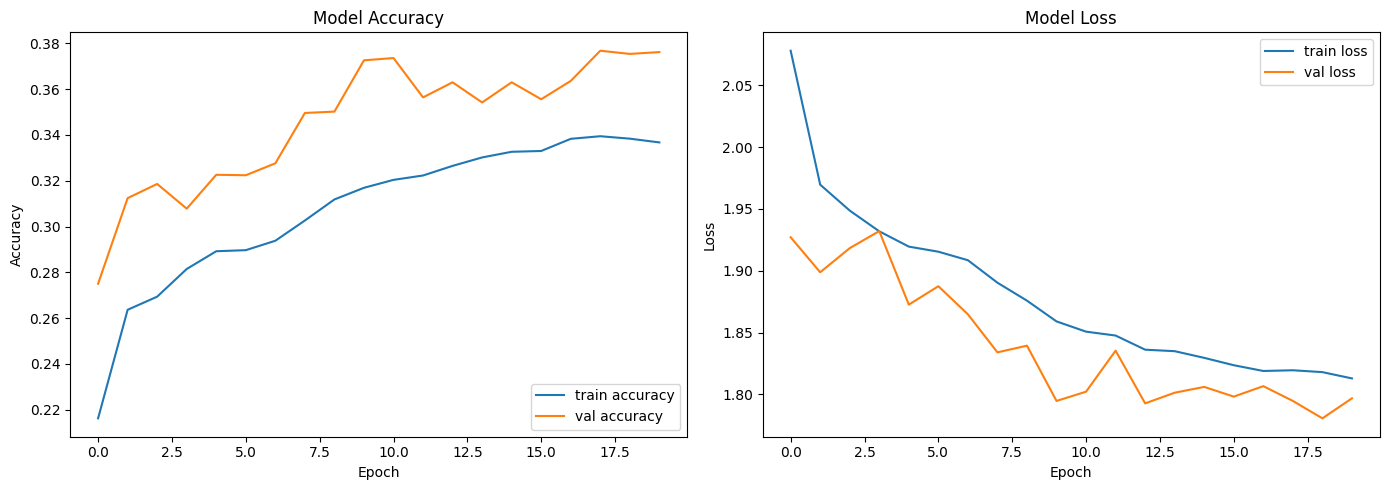

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Accuracy
axes[0].plot(model_fit.history['accuracy'],     label='train accuracy')
axes[0].plot(model_fit.history['val_accuracy'], label='val accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')

# Biểu đồ Loss
axes[1].plot(model_fit.history['loss'],     label='train loss')
axes[1].plot(model_fit.history['val_loss'], label='val loss')
axes[1].set_title('Model Loss')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Cell 9: Đánh giá model trên tập test (dữ liệu chưa thấy)

In [65]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss    :', score[0])
print('Test accuracy:', score[1])

313/313 - 2s - 5ms/step - accuracy: 0.3881 - loss: 1.7704
Test loss    : 1.770381212234497
Test accuracy: 0.3880999982357025


# Cell 10: Dự đoán nhãn cho một ảnh bất kỳ trong tập test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


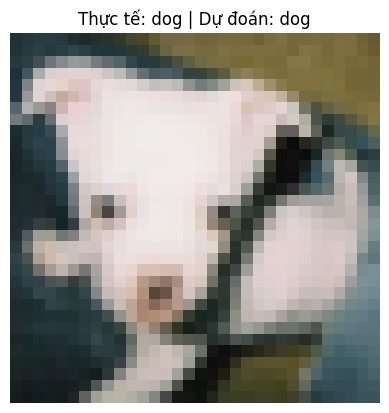

Xac suat du doan: 25.57%


In [67]:
index = random.randint(0, len(X_test)-1)

# Cần thêm chiều batch: (32,32,3) -> (1,32,32,3)
img = np.expand_dims(X_test[index], axis=0)

# Dự đoán trả về mảng xác suất cho 10 nhãn
y_pred_proba = model.predict(img)
y_pred_label = np.argmax(y_pred_proba)   # Lấy nhãn có xác suất cao nhất

# Hiển thị kết quả
plt.imshow(X_test[index])
plt.title(f"Thực tế: {class_names[y_test[index]]} | Dự đoán: {class_names[y_pred_label]}")
plt.axis('off')
plt.show()

print(f"Xac suat du doan: {y_pred_proba[0][y_pred_label]*100:.2f}%")